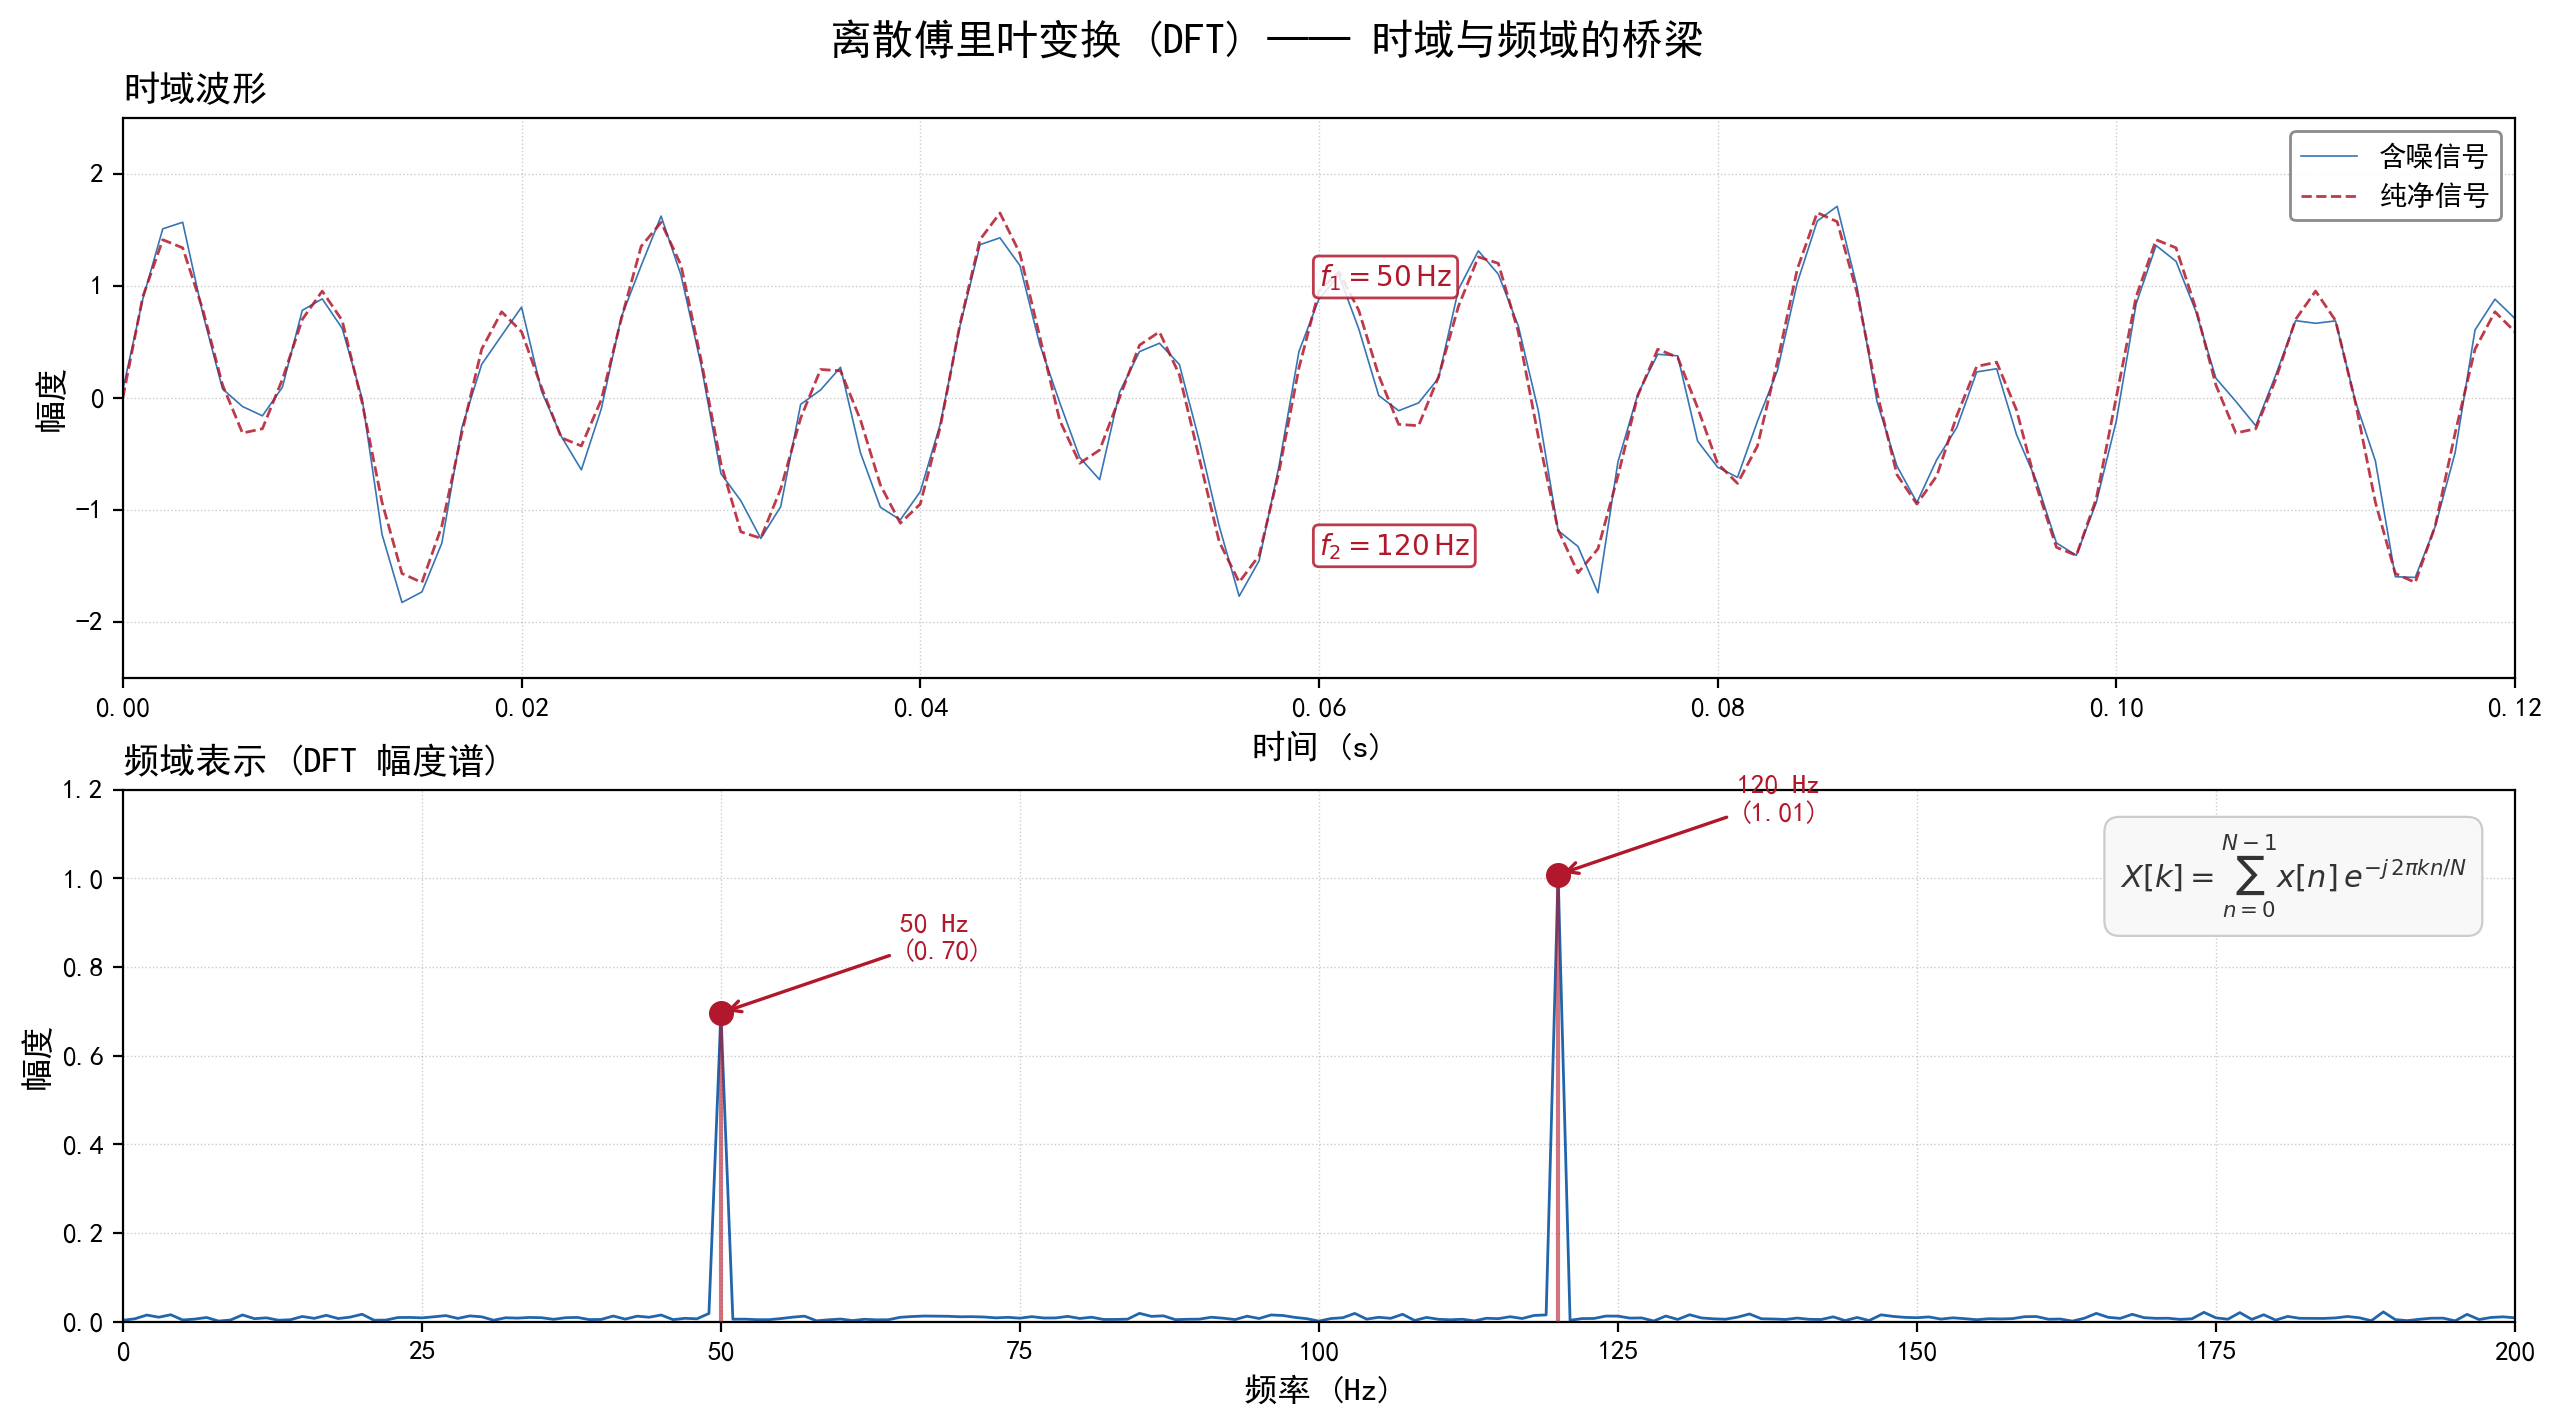

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 字体与样式配置 ---
plt.rcParams.update({
    'font.family': ['SimHei', 'Microsoft YaHei', 'sans-serif'],
    'axes.unicode_minus': False,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.0,
    'text.color': 'black',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# ====================== 1. 生成合成时域信号 ======================
fs = 1000
T = 1.0
N = int(T * fs)
t = np.linspace(0, T, N, endpoint=False)

f1, f2 = 50, 120
A1, A2 = 0.7, 1.0
x_clean = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.sin(2 * np.pi * f2 * t)

np.random.seed(42)
x = x_clean + 0.15 * np.random.normal(size=N)

# ====================== 2. DFT ======================
X = np.fft.fft(x)
freqs_full = np.fft.fftfreq(N, 1 / fs)
half = N // 2
freqs = freqs_full[:half]
X_mag = np.abs(X[:half]) / N * 2
X_mag[0] /= 2

# ====================== 3. 绘图 ======================
fig = plt.figure(figsize=(13, 7), facecolor='white')

# --- 时域子图 ---
ax1 = fig.add_axes([0.06, 0.52, 0.92, 0.40])
ax1.set_facecolor('white')
ax1.plot(t, x, color='#2166ac', linewidth=0.6, alpha=0.9)
ax1.plot(t, x_clean, color='#b2182b', linewidth=1.0, alpha=0.85, linestyle='--')
ax1.set_xlim(0, 0.12)
ax1.set_ylim(-2.5, 2.5)
ax1.set_xlabel('时间 (s)')
ax1.set_ylabel('幅度')
ax1.set_title('时域波形', loc='left', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.4, color='gray')
ax1.legend(['含噪信号', '纯净信号'], loc='upper right', framealpha=0.9,
           edgecolor='gray', facecolor='white')

# 频率标注
ax1.annotate(r'$f_1=50\,\mathrm{Hz}$', xy=(0.06, 1.0), fontsize=10,
             color='#b2182b', bbox=dict(fc='white', ec='#b2182b', alpha=0.85,
             boxstyle='round,pad=0.2'))
ax1.annotate(r'$f_2=120\,\mathrm{Hz}$', xy=(0.06, -1.4), fontsize=10,
             color='#b2182b', bbox=dict(fc='white', ec='#b2182b', alpha=0.85,
             boxstyle='round,pad=0.2'))

# --- 频域子图 ---
ax2 = fig.add_axes([0.06, 0.06, 0.92, 0.38])
ax2.set_facecolor('white')
ax2.plot(freqs, X_mag, color='#2166ac', linewidth=1.0)
ax2.set_xlim(0, 200)
ax2.set_ylim(0, 1.2)
ax2.set_xlabel('频率 (Hz)')
ax2.set_ylabel('幅度')
ax2.set_title('频域表示 (DFT 幅度谱)', loc='left', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.4, color='gray')

# 标记谱峰
for f_target, label in [(f1, '50 Hz'), (f2, '120 Hz')]:
    idx = np.abs(freqs - f_target).argmin()
    amp_val = X_mag[idx]
    ax2.plot(f_target, amp_val, 'o', color='#b2182b', markersize=8, zorder=5)
    ax2.vlines(f_target, 0, amp_val, colors='#b2182b', linewidth=1.5,
               alpha=0.6, zorder=3)
    ax2.annotate(f'{label}\n({amp_val:.2f})',
                 xy=(f_target, amp_val), xytext=(f_target + 15, amp_val + 0.12),
                 fontsize=10, color='#b2182b', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#b2182b', lw=1.2))

# --- DFT 公式（放在频域子图右上角空白处，避免挡图例） ---
ax2.text(0.98, 0.92,
         r'$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j\,2\pi kn/N}$',
         transform=ax2.transAxes,
         ha='right', va='top', fontsize=11, color='#333333',
         bbox=dict(boxstyle='round,pad=0.5', fc='#f8f8f8', ec='#cccccc', lw=0.8))

fig.suptitle('离散傅里叶变换 (DFT) —— 时域与频域的桥梁',
             fontsize=15, fontweight='bold', y=0.99)
plt.savefig('time_frequency_dft.pdf', format='pdf', facecolor='white')
plt.savefig('time_frequency_dft.png', format='png', facecolor='white')
plt.show()